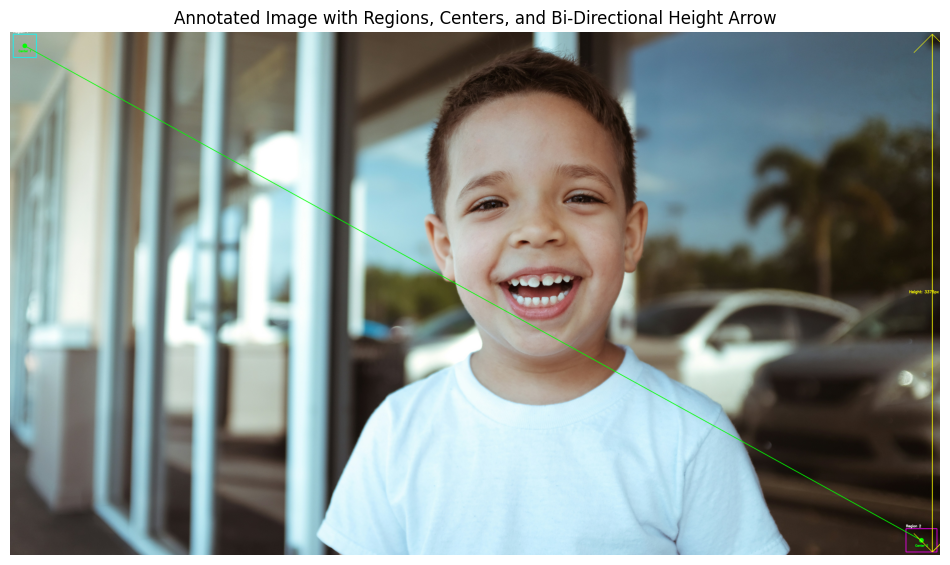

In [1]:
import cv2
import matplotlib.pyplot as plt

# Step 1: Load the Image
image_path = 'example.jpg'  # User-provided image path
image = cv2.imread(image_path)

# Convert BGR to RGB for correct color display with matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get image dimensions
height, width, _ = image_rgb.shape

# Step 2: Draw Two Rectangles Around Interesting Regions
# Rectangle 1: Top-left corner
rect1_width, rect1_height = 150, 150
top_left1 = (20, 20)  # Fixed 20 pixels padding from top-left
bottom_right1 = (top_left1[0] + rect1_width, top_left1[1] + rect1_height)
cv2.rectangle(image_rgb, top_left1, bottom_right1, (0, 255, 255), 3)  # Yellow rectangle

# Rectangle 2: Bottom-right corner
rect2_width, rect2_height = 200, 150
top_left2 = (width - rect2_width - 20, height - rect2_height - 20)  # 20 pixels padding
bottom_right2 = (top_left2[0] + rect2_width, top_left2[1] + rect2_height)
cv2.rectangle(image_rgb, top_left2, bottom_right2, (255, 0, 255), 3)  # Magenta rectangle

# Step 3: Draw Circles at the Centers of Both Rectangles
center1_x = top_left1[0] + rect1_width // 2
center1_y = top_left1[1] + rect1_height // 2
center2_x = top_left2[0] + rect2_width // 2
center2_y = top_left2[1] + rect2_height // 2
cv2.circle(image_rgb, (center1_x, center1_y), 15, (0, 255, 0), -1)  # Filled green circle
cv2.circle(image_rgb, (center2_x, center2_y), 15, (0, 255, 0), -1)  # Filled red circle

# Step 4: Draw Connecting Lines Between Centers of Rectangles
cv2.line(image_rgb, (center1_x, center1_y), (center2_x, center2_y), (0, 255, 0), 3)

# Step 5: Add Text Labels for Regions and Centers
font = cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(image_rgb, 'Region 1', (top_left1[0], top_left1[1] - 10), font, 0.7, (255, 255, 255), 2, cv2.LINE_AA)
cv2.putText(image_rgb, 'Region 2', (top_left2[0], top_left2[1] - 10), font, 0.7, (255, 255, 255), 2, cv2.LINE_AA)
cv2.putText(image_rgb, 'Center 1', (center1_x - 40, center1_y + 40), font, 0.6, (0, 255, 0), 2, cv2.LINE_AA)
cv2.putText(image_rgb, 'Center 2', (center2_x - 40, center2_y + 40), font, 0.6, (0, 255, 0), 2, cv2.LINE_AA)

# Step 6: Add Bi-Directional Arrow Representing Height
arrow_start = (width - 50, 20)  # Start near the top-right
arrow_end = (width - 50, height - 20)  # End near the bottom-right

# Draw arrows in both directions
cv2.arrowedLine(image_rgb, arrow_start, arrow_end, (255, 255, 0), 3, tipLength=0.05)  # Downward arrow
cv2.arrowedLine(image_rgb, arrow_end, arrow_start, (255, 255, 0), 3, tipLength=0.05)  # Upward arrow

# Annotate the height value
height_label_position = (arrow_start[0] - 150, (arrow_start[1] + arrow_end[1]) // 2)
cv2.putText(image_rgb, f'Height: {height}px', height_label_position, font, 0.8, (255, 255, 0), 2, cv2.LINE_AA)

# Step 7: Display the Annotated Image
plt.figure(figsize=(12, 8))
plt.imshow(image_rgb)
plt.title('Annotated Image with Regions, Centers, and Bi-Directional Height Arrow')
plt.axis('off')
plt.show()
